# Rabis

In [2]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
from scipy import stats
from scipy.optimize import curve_fit
import scipy.signal as peak

# directory structure
current_file = 'IH lines.ipynb'
current_dir = os.path.dirname(os.path.abspath(current_file)) # Angela Experiments
print(current_dir)
parent_dir = os.path.dirname(current_dir) # Longterm_sweeps
print(parent_dir)

# append parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")

# import functions!!
import qil_helpers.Angela.angelaHelpers as ang

c:\Users\Mario\Documents\GitHub\longterm_sweeps\analysis
c:\Users\Mario\Documents\GitHub\longterm_sweeps


### Functions

In [3]:
def damped_sin(x, x0, A, w, damp, C):
    return A * np.sin(w * x - x0) * np.exp(-damp * (x - x0)) + C

def damped_sin_fit(data, mask):
    # unpack data from input
    x = data[:, 0]
    y = data[:, 1]

    # create a boolean mask to identify valid (non-NaN) data points
    valid_mask = ~np.isnan(x) & ~mask
    x_filtered = x[valid_mask]
    y_filtered = y[valid_mask]

    # initial guess for parameters
    x0_guess = 0
    A_guess = 0.5 * (np.max(y_filtered) - np.min(y_filtered))
    w_guess = 10
    damp_guess = 0.1
    C_guess = np.mean(y_filtered)
    p0 = [x0_guess, A_guess, w_guess, damp_guess, C_guess]

    # fit lorentzian to data
    popt, pcov = curve_fit(damped_sin, 
                           x_filtered, 
                           y_filtered,
                           p0 = p0,
                           maxfev = int(1e5))
    x0 = [popt[0], np.sqrt(pcov[0,0])]   
    A = [popt[1], np.sqrt(pcov[1,1])]   
    w = [popt[2], np.sqrt(pcov[2,2])]   
    damp = [popt[3], np.sqrt(pcov[3,3])]
    C = [popt[4], np.sqrt(pcov[4,4])]

    return x0, A, w, damp, C

# Write function to filter histograms by nearest neighbour



# 16/03/2026
SiC at 1522nm

Frequency fit: 9.889385409944321 +/- 8.42707716314306
Damping fit: 9.3429740514611 +/- 16.319150440670473
Amplitude fit: 2214166.7681973 +/- 187879100.7023582
Sum over 2.0 ms


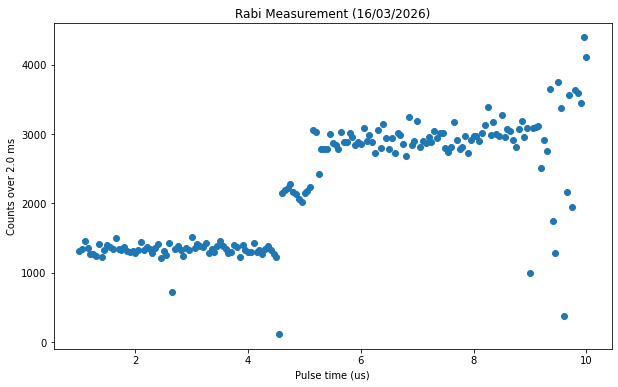

In [10]:
data_directory = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-16\sic\rabi\1522.51 nm\run2"
numBins = 100
pis = []
counts = []

# for i, file in enumerate(os.listdir(data_directory)[0:34]):
for i, file in enumerate(os.listdir(data_directory)):
    # Extract data and info
    file_path = os.path.join(data_directory, file)
    data_read = np.loadtxt(file_path, delimiter = ',')
    times, data = data_read[0], data_read[1]
    pis.append(float(file.split("_")[-2]))

    # Sum over numBins
    counts.append(np.sum(data[0:numBins + 1]))
    timeLimit = times[numBins]

# Fit a damped sinusoid
data = np.column_stack((pis, counts))
x0, A, w, damp, C = damped_sin_fit(data, np.zeros(len(data), dtype = bool))
pis = np.array(pis)
counts = np.array(counts)
print(f"Frequency fit: {w[0]} +/- {w[1]}")
print(f"Damping fit: {damp[0]} +/- {damp[1]}")
print(f"Amplitude fit: {A[0]} +/- {A[1]}")

# Plot everything
print(f"Sum over {timeLimit*1e3} ms")
plt.figure(figsize = (10,6))
plt.xlabel('Pulse time (us)')
# plt.ylim([0, 1e3])
plt.ylabel(f'Counts over {timeLimit*1e3} ms')
plt.scatter(pis, np.array(counts))
pi_range = np.linspace(min(pis), max(pis), 100)
# plt.plot(pi_range, damped_sin(pi_range, x0[0], A[0], w[0], damp[0], C[0]), 'red')
plt.title('Rabi Measurement (16/03/2026)')
plt.show()

# 17/03/2026
SiC at 1528nm

Frequency fit: 6.439639252328401 +/- 0.726036318275259
Damping fit: -2.446991496710759 +/- 1.0535303910399298
Amplitude fit: -1.2671762886557006e-15 +/- 2.3301396473337653e-14
Sum over 2.0 ms


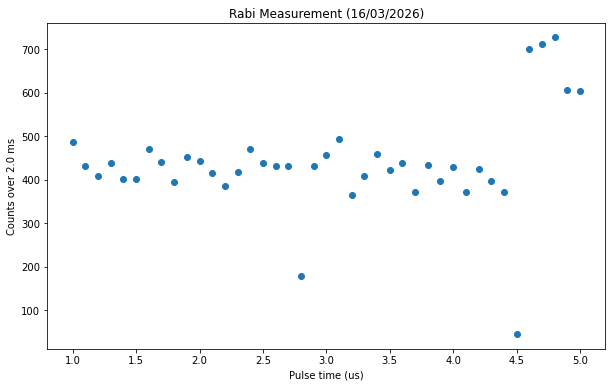

In [12]:
data_directory = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-17\sic\rabi\1522.51 nm\run1"
numBins = 100
pis = []
counts = []

for i, file in enumerate(os.listdir(data_directory)):
    # Extract data and info
    file_path = os.path.join(data_directory, file)
    data_read = np.loadtxt(file_path, delimiter = ',')
    times, data = data_read[0], data_read[1]
    pis.append(float(file.split("_")[-2]))

    # Sum over numBins
    counts.append(np.sum(data[0:numBins + 1]))
    timeLimit = times[numBins]

# Fit a damped sinusoid
data = np.column_stack((pis, counts))
x0, A, w, damp, C = damped_sin_fit(data, np.zeros(len(data), dtype = bool))
pis = np.array(pis)
counts = np.array(counts)
print(f"Frequency fit: {w[0]} +/- {w[1]}")
print(f"Damping fit: {damp[0]} +/- {damp[1]}")
print(f"Amplitude fit: {A[0]} +/- {A[1]}")

# Plot everything
print(f"Sum over {timeLimit*1e3} ms")
plt.figure(figsize = (10,6))
plt.xlabel('Pulse time (us)')
# plt.ylim([0, 1e3])
plt.ylabel(f'Counts over {timeLimit*1e3} ms')
plt.scatter(pis, np.array(counts))
pi_range = np.linspace(min(pis), max(pis), 100)
# plt.plot(pi_range, damped_sin(pi_range, x0[0], A[0], w[0], damp[0], C[0]), 'red')
plt.title('Rabi Measurement (16/03/2026)')
plt.show()

Frequency fit: 6.165882647933061 +/- 0.7232473796604848
Damping fit: -1.5436084840985458 +/- 0.91405662891092
Amplitude fit: -3.319999552477876e-05 +/- 0.00031705173384361565
Sum over 2.0 ms


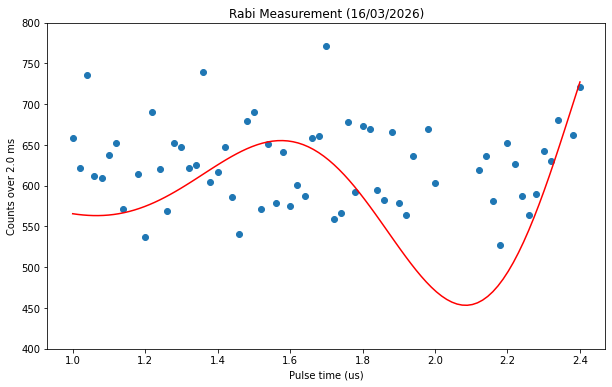

In [15]:
data_directory = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-17\sic\rabi\1528.85 nm\run2"
numBins = 100
pis = []
counts = []

for i, file in enumerate(os.listdir(data_directory)):
    # Extract data and info
    file_path = os.path.join(data_directory, file)
    data_read = np.loadtxt(file_path, delimiter = ',')
    times, data = data_read[0], data_read[1]
    pis.append(float(file.split("_")[-2]))

    # Sum over numBins
    counts.append(np.sum(data[0:numBins + 1]))
    timeLimit = times[numBins]

# Fit a damped sinusoid
data = np.column_stack((pis, counts))
x0, A, w, damp, C = damped_sin_fit(data, np.zeros(len(data), dtype = bool))
pis = np.array(pis)
counts = np.array(counts)
print(f"Frequency fit: {w[0]} +/- {w[1]}")
print(f"Damping fit: {damp[0]} +/- {damp[1]}")
print(f"Amplitude fit: {A[0]} +/- {A[1]}")

# Plot everything
print(f"Sum over {timeLimit*1e3} ms")
plt.figure(figsize = (10,6))
plt.xlabel('Pulse time (us)')
plt.ylim([400, 800])
plt.ylabel(f'Counts over {timeLimit*1e3} ms')
plt.scatter(pis, np.array(counts))
pi_range = np.linspace(min(pis), max(pis), 100)
plt.plot(pi_range, damped_sin(pi_range, x0[0], A[0], w[0], damp[0], C[0]), 'red')
plt.title('Rabi Measurement (16/03/2026)')
plt.show()

Sum over 1.0 ms


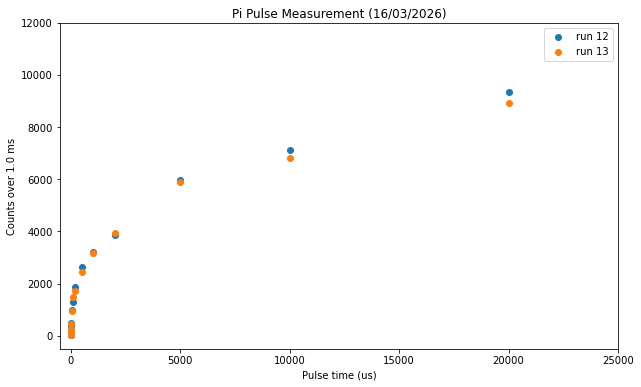

In [34]:
data_directory = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-17\sic\fake rabi\1528.85 nm\run13"
numBins = 100
pis1 = []
counts1 = []
for i, file in enumerate(os.listdir(data_directory)):
    # Extract data and info
    file_path = os.path.join(data_directory, file)
    data_read = np.loadtxt(file_path, delimiter = ',')
    times, data = data_read[0], data_read[1]
    pis1.append(float(file.split("_")[-2]))

    # Sum over numBins
    counts1.append(np.sum(data[0:numBins + 1]))

data_directory = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\2026-03-17\sic\fake rabi\1528.85 nm\run12"
numBins = 100
pis2 = []
counts2 = []
for i, file in enumerate(os.listdir(data_directory)):
    # Extract data and info
    file_path = os.path.join(data_directory, file)
    data_read = np.loadtxt(file_path, delimiter = ',')
    times, data = data_read[0], data_read[1]
    pis2.append(float(file.split("_")[-2]))

    # Sum over numBins
    counts2.append(np.sum(data[0:numBins + 1]))
    timeLimit = times[numBins]

# Plot everything
print(f"Sum over {timeLimit*1e3} ms")
plt.figure(figsize = (10,6))
plt.scatter(pis1, np.array(counts1)*2, label = 'run 12') # period * 1e3 intTime
plt.scatter(pis2, np.array(counts2), label = 'run 13') # period * 2e3 intTime

plt.legend()
plt.xlim([-500, 2.5e4])
plt.ylim([-500, 12e3])
plt.xlabel('Pulse time (us)')
plt.ylabel(f'Counts over {timeLimit*1e3} ms')
plt.title('Pi Pulse Measurement (16/03/2026)')
plt.show()